qiskit_runtime_service.__init__:WARNING:2026-09-29 12:31:49,124: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService(). Alternatively, pass instance='auto' or save it to your account for auto-selection without warning.
qiskit_runtime_service.backends:WARNING:2026-09-29 12:31:49,124: Using instance: open-instance, plan: open


Qubit 0
Reported T1 = 212.70 us
Reported T2 = 303.18 us


/Users/raifefoulkes/Desktop/PlayingWQiskit/.venv/lib/python3.13/site-packages/qiskit/circuit/duration.py:37: UserWarning: Duration is rounded to 13294 [dt] = 5.317600e-05 [s] from 5.317463e-05 [s]
  warnings.warn(
/Users/raifefoulkes/Desktop/PlayingWQiskit/.venv/lib/python3.13/site-packages/qiskit/circuit/duration.py:37: UserWarning: Duration is rounded to 9474 [dt] = 3.789600e-05 [s] from 3.789770e-05 [s]
  warnings.warn(
/Users/raifefoulkes/Desktop/PlayingWQiskit/.venv/lib/python3.13/site-packages/qiskit/circuit/duration.py:37: UserWarning: Duration is rounded to 26587 [dt] = 1.063480e-04 [s] from 1.063493e-04 [s]
  warnings.warn(
/Users/raifefoulkes/Desktop/PlayingWQiskit/.venv/lib/python3.13/site-packages/qiskit/circuit/duration.py:37: UserWarning: Duration is rounded to 18949 [dt] = 7.579600e-05 [s] from 7.579539e-05 [s]
  warnings.warn(
/Users/raifefoulkes/Desktop/PlayingWQiskit/.venv/lib/python3.13/site-packages/qiskit/circuit/duration.py:37: UserWarning: Duration is rounded to 

Job ID: datq3djojkfs738r4bug


<ErrorbarContainer object of 3 artists>

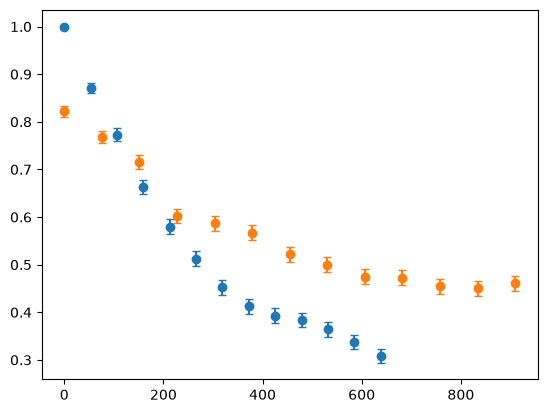

In [22]:
import numpy as np
import matplotlib.pyplot as plt

from qiskit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2
from qiskit_aer import AerSimulator

service = QiskitRuntimeService()

real_backend = service.backend("ibm_kingston")

#print("Backend:", backend.name)

#backend = AerSimulator.from_backend(real_backend)
backend = real_backend

#choose physical qubit (first one)
q = 0

#get current reported calibration properties
props = real_backend.properties(refresh=True)

T1_reported = props.t1(q)
T2_reported = props.t2(q)

print(f"Qubit {q}")
print(f"Reported T1 = {T1_reported * 1e6:.2f} us")
print(f"Reported T2 = {T2_reported * 1e6:.2f} us")


#range time over 3x their reported T1 to get enough data for exponential
t1times = np.linspace(0, 3 * T1_reported, 13)
t2times = np.linspace(0, 3 * T2_reported, 13)

#build 13 T1 circuits - 13 bc cheap for testing but enough to see the curve
circuits = []
experiment_info = []

for t1, t2 in zip(t1times, t2times):
    qc1 = QuantumCircuit(1)
    #prepare 1
    qc1.x(0)
    #relax for time t
    qc1.delay(t1, 0, unit="s")
    #measure
    qc1.measure_all()
    circuits.append(qc1)
    experiment_info.append(("T1", t1))

    qc2 = QuantumCircuit(1)
    qc2.h(0)
    qc2.delay(t2/2, 0, unit="s")
    qc2.x(0)
    qc2.delay(t2/2, 0, unit="s")
    qc2.h(0)
    qc2.measure_all()
    circuits.append(qc2)
    experiment_info.append(("T2", t2))

#transpile onto physical qubit q
pm = generate_preset_pass_manager(
    backend=backend,
    optimization_level=1,
    initial_layout=[q],
    scheduling_method="alap"
)

isa_circuits = pm.run(circuits)


#run all delay points in onejob
sampler = SamplerV2(mode=backend)

shots = 1000

job = sampler.run(
    isa_circuits,
    shots=shots
)

print("Job ID:", job.job_id())

result = job.result()


p1 = []
e1 = []

p0 = []
e0 = []

for r, (experiment, t) in zip(result, experiment_info):

    counts = r.data.meas.get_counts()
    N = sum(counts.values())

    if experiment == "T1":
        p = counts.get("1", 0) / N

        p1.append(p)
        e1.append(np.sqrt(p * (1-p) / N))

    elif experiment == "T2":
        p = counts.get("0", 0) / N

        p0.append(p)
        e0.append(np.sqrt(p * (1-p) / N))


p1 = np.array(p1)
e1 = np.array(e1)

p0 = np.array(p0)
e0 = np.array(e0)

plt.errorbar(
    t1times * 1e6,
    p1,
    yerr=e1,
    fmt="o",
    capsize=3,
    label="Aer simulation"
)
plt.errorbar(
    t2times * 1e6,
    p0,
    yerr=e0,
    fmt="o",
    capsize=3,
    label="Aer simulation"
)

IBM Kingston - T1
Curve-fit T1 = 267.08 +/- 13.94 us
Reported T1  = 212.70 us
Curve fit:      A = 0.7541, c = 0.2450
Reported-T1 fit: A = 0.6925, c = 0.3069


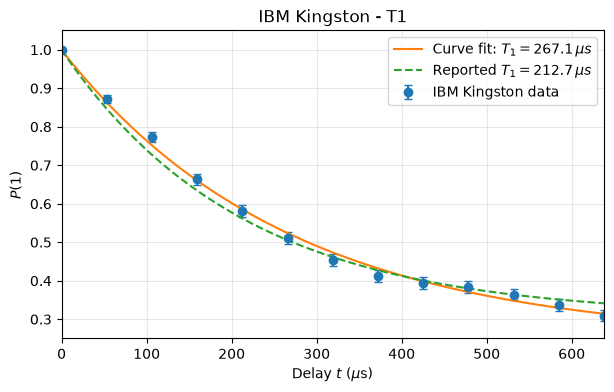

IBM Kingston - T2
Curve-fit T2 = 354.33 +/- 46.58 us
Reported T2  = 303.18 us
Curve fit:      A = 0.4241, c = 0.4104
Reported-T2 fit: A = 0.4110, c = 0.4316


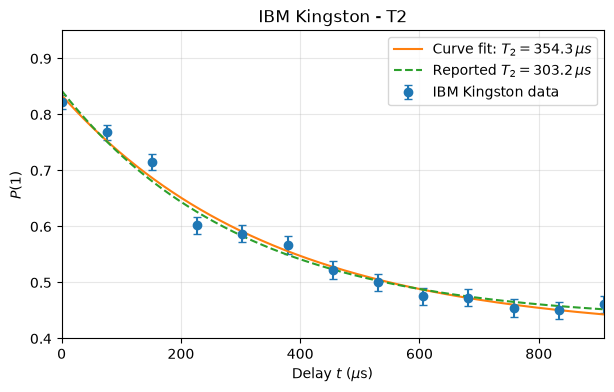

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def exponentialFunc(t, A, T1, c):
    return A * np.exp(-t / T1) + c


def plot_T1_run(times, p1, T1_reported, run_name,e1):
    #in case there are any 0 errors doing this to avoid divide by zero
    errors = np.maximum(e1, 1e-6)

    #curve fit to data
    res, cov = curve_fit(
        exponentialFunc,
        times,
        p1,
        p0=[0.8, T1_reported, 0.1], sigma=errors
    )

    A_fit, T1_fit, c_fit = res
    T1_error = np.sqrt(cov[1, 1])

    #fix T1 = reported T1 and least-squares fit A,c
    def reportedT1Func(t, A, c):
        return A * np.exp(-t / T1_reported) + c

    res_reported, cov_reported = curve_fit(
        reportedT1Func,
        times,
        p1,
        p0=[0.8, 0.1],
        sigma=errors,
        absolute_sigma=True
    )

    A_reported, c_reported = res_reported

    #make a finer grid for plots
    t_fine = np.linspace(
        times.min(),
        times.max(),
        500
    )

    #free T1 best fit
    curve_fit_values = exponentialFunc(
        t_fine,
        A_fit,
        T1_fit,
        c_fit
    )

    #reported T1, but optimal A and c
    reported_curve_values = (
        A_reported * np.exp(-t_fine / T1_reported)
        + c_reported
    )

    #print values

    print(f"{run_name}")
    print(
        f"Curve-fit T1 = {T1_fit*1e6:.2f} "
        f"+/- {T1_error*1e6:.2f} us"
    )
    print(f"Reported T1  = {T1_reported*1e6:.2f} us")

    print(
        f"Curve fit:      A = {A_fit:.4f}, "
        f"c = {c_fit:.4f}"
    )

    print(
        f"Reported-T1 fit: A = {A_reported:.4f}, "
        f"c = {c_reported:.4f}"
    )

    #plot
    plt.figure(figsize=(7, 4))

    plt.errorbar(
        times * 1e6,
        p1,
        yerr=e1,
        fmt="o",
        capsize=3,
        label="IBM Kingston data"
    )

    plt.plot(
        t_fine * 1e6,
        curve_fit_values,
        label=fr"Curve fit: $T_1={T1_fit*1e6:.1f}\,\mu s$"
    )

    plt.plot(
        t_fine * 1e6,
        reported_curve_values,
        linestyle="--",
        label=fr"Reported $T_1={T1_reported*1e6:.1f}\,\mu s$"
    )

    plt.xlabel(r"Delay $t$ ($\mu$s)")
    plt.ylabel(r"$P(1)$")

    plt.ylim(0.25, 1.05)
    plt.xlim(
        times.min() * 1e6,
        times.max() * 1e6
    )

    plt.grid(alpha=0.3)
    plt.legend()
    plt.title(run_name)

    plt.show()

def plot_T2_run(times, p0, T2_reported, run_name,e0):
    #in case there are any 0 errors doing this to avoid divide by zero
    errors = np.maximum(e0, 1e-6)

    #curve fit to data
    res, cov = curve_fit(
        exponentialFunc,
        times,
        p0,
        p0=[0.8, T2_reported, 0.1], sigma=errors
    )

    A_fit, T2_fit, c_fit = res
    T2_error = np.sqrt(cov[1, 1])

    #fix T1 = reported T1 and least-squares fit A,c
    def reportedT2Func(t, A, c):
        return A * np.exp(-t / T2_reported) + c

    res_reported, cov_reported = curve_fit(
        reportedT2Func,
        times,
        p0,
        p0=[0.8, 0.1],
        sigma=errors,
        absolute_sigma=True
    )

    A_reported, c_reported = res_reported

    #make a finer grid for plots
    t_fine = np.linspace(
        times.min(),
        times.max(),
        500
    )

    #free T2 best fit
    curve_fit_values = exponentialFunc(
        t_fine,
        A_fit,
        T2_fit,
        c_fit
    )

    #reported T2, but optimal A and c
    reported_curve_values = (
        A_reported * np.exp(-t_fine / T2_reported)
        + c_reported
    )

    #print values

    print(f"{run_name}")
    print(
        f"Curve-fit T2 = {T2_fit*1e6:.2f} "
        f"+/- {T2_error*1e6:.2f} us"
    )
    print(f"Reported T2  = {T2_reported*1e6:.2f} us")

    print(
        f"Curve fit:      A = {A_fit:.4f}, "
        f"c = {c_fit:.4f}"
    )

    print(
        f"Reported-T2 fit: A = {A_reported:.4f}, "
        f"c = {c_reported:.4f}"
    )

    #plot
    plt.figure(figsize=(7, 4))

    plt.errorbar(
        times * 1e6,
        p0,
        yerr=e0,
        fmt="o",
        capsize=3,
        label="IBM Kingston data"
    )

    plt.plot(
        t_fine * 1e6,
        curve_fit_values,
        label=fr"Curve fit: $T_2={T2_fit*1e6:.1f}\,\mu s$"
    )

    plt.plot(
        t_fine * 1e6,
        reported_curve_values,
        linestyle="--",
        label=fr"Reported $T_2={T2_reported*1e6:.1f}\,\mu s$"
    )

    plt.xlabel(r"Delay $t$ ($\mu$s)")
    plt.ylabel(r"$P(1)$")

    plt.ylim(0.4, 0.95)
    plt.xlim(
        times.min() * 1e6,
        times.max() * 1e6
    )

    plt.grid(alpha=0.3)
    plt.legend()
    plt.title(run_name)

    plt.show()

# FIRST EXPERIMENTAL RUN
plot_T1_run(
    t1times,
    p1,
    T1_reported,
    "IBM Kingston - T1",
    e1=e1
)
plot_T2_run(
    t2times,
    p0,
    T2_reported,
    "IBM Kingston - T2",
    e0=e0
)